<h1> Sales Analysis For AAL</h1>

<h2 style="color:darkred"> Load Data </h2>

In [432]:
# Load Data from CSV File
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

aus_sales4thQtr_2020 = pd.read_csv('AusApparalSales4thQrt2020.csv')

In [433]:
# Verify the loaded data
aus_sales4thQtr_2020.head()

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


In [434]:
# Describe the data
aus_sales4thQtr_2020.describe()

,Unit,Sales
count,7560.000000,7560.000000
mean,18.005423,45013.558201
std,12.901403,32253.506944
min,2.000000,5000.000000
25%,8.000000,20000.000000
50%,14.000000,35000.000000
75%,26.000000,65000.000000
max,65.000000,162500.000000


In [435]:
# Info of the data
aus_sales4thQtr_2020.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


<h2 style="color:darkred"> 1. Data wrangling </h2>
<h4 style="color:purple"> A. Ensure that the data is clean and free from any missing or incorrect entries. </h4>
Inspect the data manually to identify missing or incorrect information using the functions isna() and notna().

In [436]:
# Check for the count of exisitng values
aus_sales4thQtr_2020.notna()

,Date,Time,State,Group,Unit,Sales
0,True,True,True,True,True,True
1,True,True,True,True,True,True
2,True,True,True,True,True,True
3,True,True,True,True,True,True
4,True,True,True,True,True,True
...,...,...,...,...,...,...
7555,True,True,True,True,True,True
7556,True,True,True,True,True,True
7557,True,True,True,True,True,True
7558,True,True,True,True,True,True


In [437]:
# Check for missing values
aus_sales4thQtr_2020.isna()

,Date,Time,State,Group,Unit,Sales
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
7555,False,False,False,False,False,False
7556,False,False,False,False,False,False
7557,False,False,False,False,False,False
7558,False,False,False,False,False,False


In [438]:
print(f"Filled values \n{aus_sales4thQtr_2020.notna().sum()}",end="\n\n")
print(f"Missing values \n{aus_sales4thQtr_2020.isna().sum()}")

Filled values 
Date     7560
Time     7560
State    7560
Group    7560
Unit     7560
Sales    7560
dtype: int64

Missing values 
Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64


<h4 style="color:green"> From the above functions we're seeing not having any missing values in the given dataset.</h4>

<h4 style="color:purple"> B. Based on your knowledge of data analytics, include your recommendations for treating missing and incorrect data (dropping the null values or filling them). </h4>

In [439]:
# To filter and view the exact rows containing nulls.
aus_sales4thQtr_2020[aus_sales4thQtr_2020.isnull().any(axis=1)]

,Date,Time,State,Group,Unit,Sales


In [440]:
# Check Entire Dataset: Use df.isnull().values.any() to get a quick True/False if any null exists anywhere.
aus_sales4thQtr_2020.isnull().values.any()

np.False_

In [441]:
# Whitespace and Empty Strings: Sometimes a cell looks empty but contains a space. Check for these using
aus_sales4thQtr_2020.astype(str).apply(lambda x: x.str.strip() == '').sum()

Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

In [442]:
# Look for common manual entries like "?", "N/A", "null" (as a string), or filler numbers like "999". You can search for these specifically
placeholders = ['?', 'n/a', 'missing', 999]
aus_sales4thQtr_2020.isin(placeholders).sum()

Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

In [443]:
# Checks for the duplicated data
aus_sales4thQtr_2020.duplicated().sum()

np.int64(0)

In [444]:
# Check negative sales values
aus_sales4thQtr_2020[aus_sales4thQtr_2020['Sales'] < 0]

,Date,Time,State,Group,Unit,Sales


In [445]:
aus_sales4thQtr_2020 = aus_sales4thQtr_2020[aus_sales4thQtr_2020['Sales'] >= 0]
aus_sales4thQtr_2020.count()

Date     7560
Time     7560
State    7560
Group    7560
Unit     7560
Sales    7560
dtype: int64

In [446]:
# Change date column to datetime
aus_sales4thQtr_2020['Date'] = pd.to_datetime(aus_sales4thQtr_2020['Date'])

## Observation from Dataset

1. The dataset does not contain any missing values.

   If missing values were present:
   
   - We can use `dropna()` to remove null records.
   - We can use `fillna()` with mean/median for numerical columns like `Sales` and `Unit`.
   - We can use `fillna()` with mode for categorical columns.
---

2. The dataset does not contain any duplicate records.

   If duplicate values were present:
   
   - We can use `drop_duplicates()` to remove duplicate records.
---

3. The dataset does not contain any empty string values.
---
4. The dataset does not contain any irrelevant strings.
---
5. The dataset does not contain any invalid data entries.


#### Data is clean and does not require any further cleaning.

<h4 style="color:purple"> C. Choose a suitable data wrangling technique—either data standardization or normalization. Execute the preferred normalization method and present the resulting data. (Normalization is the preferred approach for this problem). </h4>

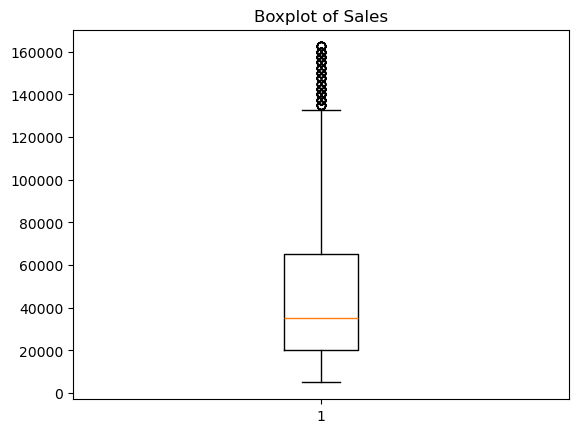

In [447]:
# To check the outliers using boxplot
plt.boxplot(aus_sales4thQtr_2020['Sales'])
plt.title('Boxplot of Sales')
plt.show()

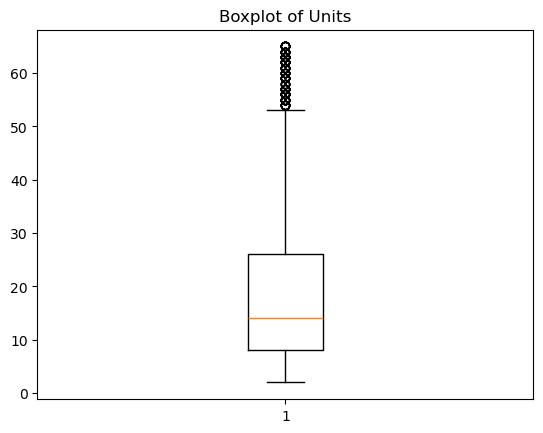

In [448]:
# To check the outliers using boxplot
plt.boxplot(aus_sales4thQtr_2020['Unit'])
plt.title('Boxplot of Units')
plt.show()

## Observation from Data set

1. Sales Data is not having many extreme outliers.
2. Units Data is not having many extreme outliers

<h4> Since Data is not having many extreme outliers choosing Min Max Normalization </h4>

<h3>Min-Max Normalization For Numerical Columns Sales,Unit</h3>

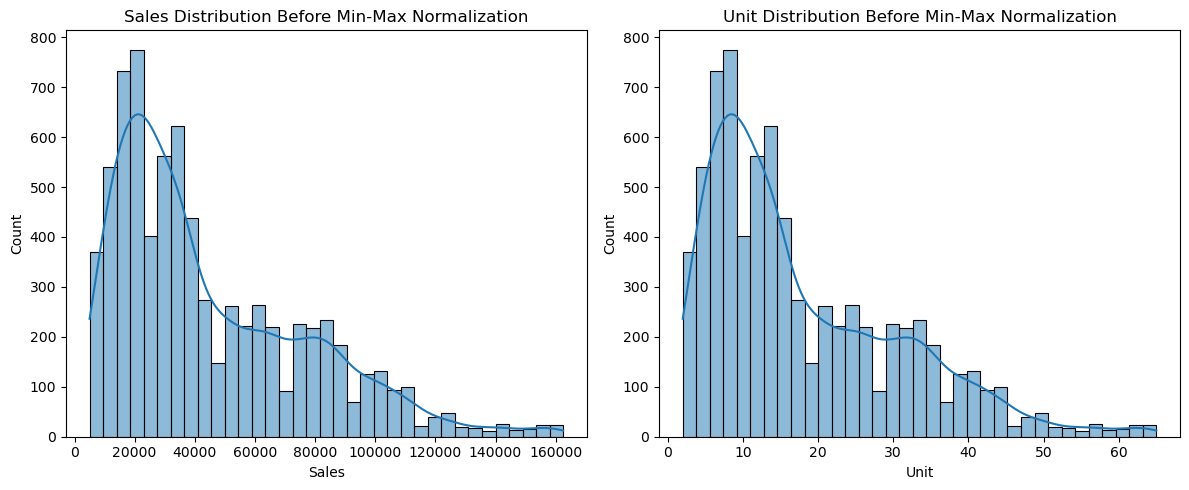

In [449]:
# Before Normalization Sales, Units Data
plt.figure(figsize=(12,5))
# Sales distribution
plt.subplot(1,2,1)
sns.histplot(aus_sales4thQtr_2020['Sales'], kde=True)
plt.title('Sales Distribution Before Min-Max Normalization')

# Unit distribution
plt.subplot(1,2,2)
sns.histplot(aus_sales4thQtr_2020['Unit'], kde=True)
plt.title('Unit Distribution Before Min-Max Normalization')

plt.tight_layout()
plt.show()

In [450]:
# Performing min-max on numerical columns sales,unit

numerical_col = ['Sales','Unit']

for col in numerical_col:
    col_max = aus_sales4thQtr_2020[col].max()
    col_min = aus_sales4thQtr_2020[col].min()
    aus_sales4thQtr_2020[col] = (aus_sales4thQtr_2020[col] - col_min) / (col_max - col_min)

aus_sales4thQtr_2020.head()

,Date,Time,State,Group,Unit,Sales
0,2020-10-01,Morning,WA,Kids,0.095238,0.095238
1,2020-10-01,Morning,WA,Men,0.095238,0.095238
2,2020-10-01,Morning,WA,Women,0.031746,0.031746
3,2020-10-01,Morning,WA,Seniors,0.206349,0.206349
4,2020-10-01,Afternoon,WA,Kids,0.015873,0.015873


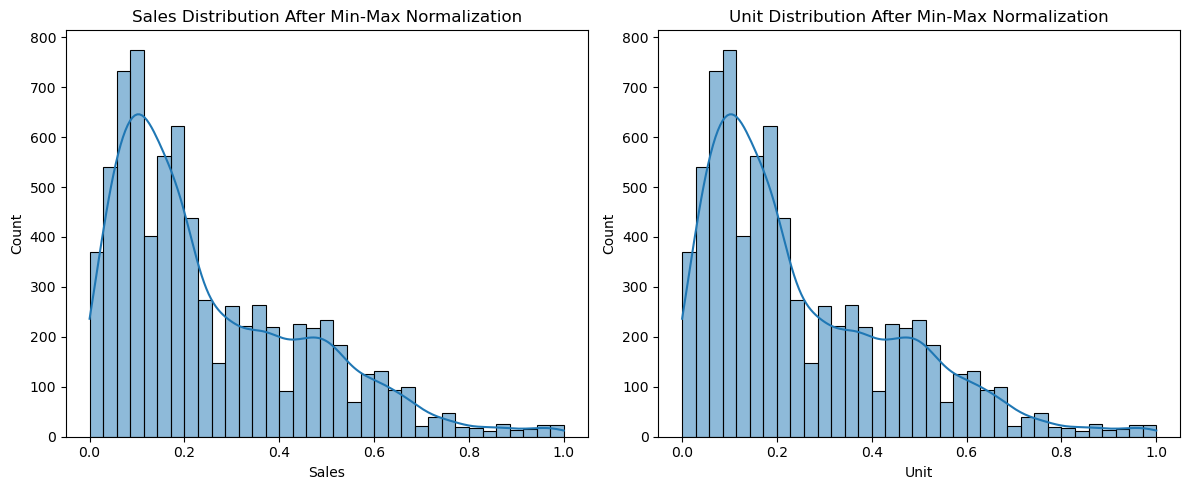

In [451]:
# After normalization sale,unit data
plt.figure(figsize=(12,5))

# Sales distribution
plt.subplot(1,2,1)
sns.histplot(aus_sales4thQtr_2020['Sales'], kde=True)
plt.title('Sales Distribution After Min-Max Normalization')

# Unit distribution
plt.subplot(1,2,2)
sns.histplot(aus_sales4thQtr_2020['Unit'], kde=True)
plt.title('Unit Distribution After Min-Max Normalization')

plt.tight_layout()
plt.show()

<h4 style="color:purple"> D. Share your insights regarding the application of the GroupBy() function for either data chunking or merging, and offer a recommendation based on your analysis.. </h4>

<h4 > Insights of Groupby() </h4>

<h5> Provides deeper analysis of: </h5>

1. Which customer group performs best in each state
2. Which state having more sales
3. Which state and customer groups having demand
4. Which month sale are higher
5. At which time of the day having more sales

<h4> Business Benefit: </h4>
<h5> Supports: </h5>

1. Regional marketing strategies
2. Personalized promotions based on group
3. Demand forecasting
4. Staff adjustment OR Resources planning

We can also perform

1. Identifying high-revenue states
2. Finding low-performing states
3. Comparing sales across customer groups

In [452]:
# State wise sales
state_sales = aus_sales4thQtr_2020.groupby('State')['Sales'].sum().reset_index()
state_sales

,State,Sales
0,NSW,441.714286
1,NT,109.079365
2,QLD,177.888889
3,SA,339.412698
4,TAS,110.222222
5,VIC,635.968254
6,WA,106.365079


In [453]:
# State and Group Sales
state_group_sales = aus_sales4thQtr_2020.groupby(['State','Group'])['Sales'].sum().reset_index()
state_group_sales

,State,Group,Sales
0,NSW,Kids,109.444444
1,NSW,Men,112.206349
2,NSW,Seniors,106.904762
3,NSW,Women,113.158730
4,NT,Kids,27.619048
5,NT,Men,28.015873
6,NT,Seniors,26.126984
7,NT,Women,27.317460
8,QLD,Kids,45.460317
9,QLD,Men,44.714286


In [454]:
# Group wise sales
group_sales = aus_sales4thQtr_2020.groupby(['Group'])['Sales'].sum().reset_index()
group_sales

,Group,Sales
0,Kids,480.142857
1,Men,484.444444
2,Seniors,473.571429
3,Women,482.492063


In [455]:
# Month wise sales

# Adding feature Month to the dataframe
aus_sales4thQtr_2020['Month'] = aus_sales4thQtr_2020['Date'].dt.month_name()
aus_sales4thQtr_2020.head()

,Date,Time,State,Group,Unit,Sales,Month
0,2020-10-01,Morning,WA,Kids,0.095238,0.095238,October
1,2020-10-01,Morning,WA,Men,0.095238,0.095238,October
2,2020-10-01,Morning,WA,Women,0.031746,0.031746,October
3,2020-10-01,Morning,WA,Seniors,0.206349,0.206349,October
4,2020-10-01,Afternoon,WA,Kids,0.015873,0.015873,October


In [456]:
# Month wise sales
monthly_sales = aus_sales4thQtr_2020.groupby('Month')['Sales'].sum().reset_index()
monthly_sales

,Month,Sales
0,December,779.238095
1,November,495.761905
2,October,645.650794


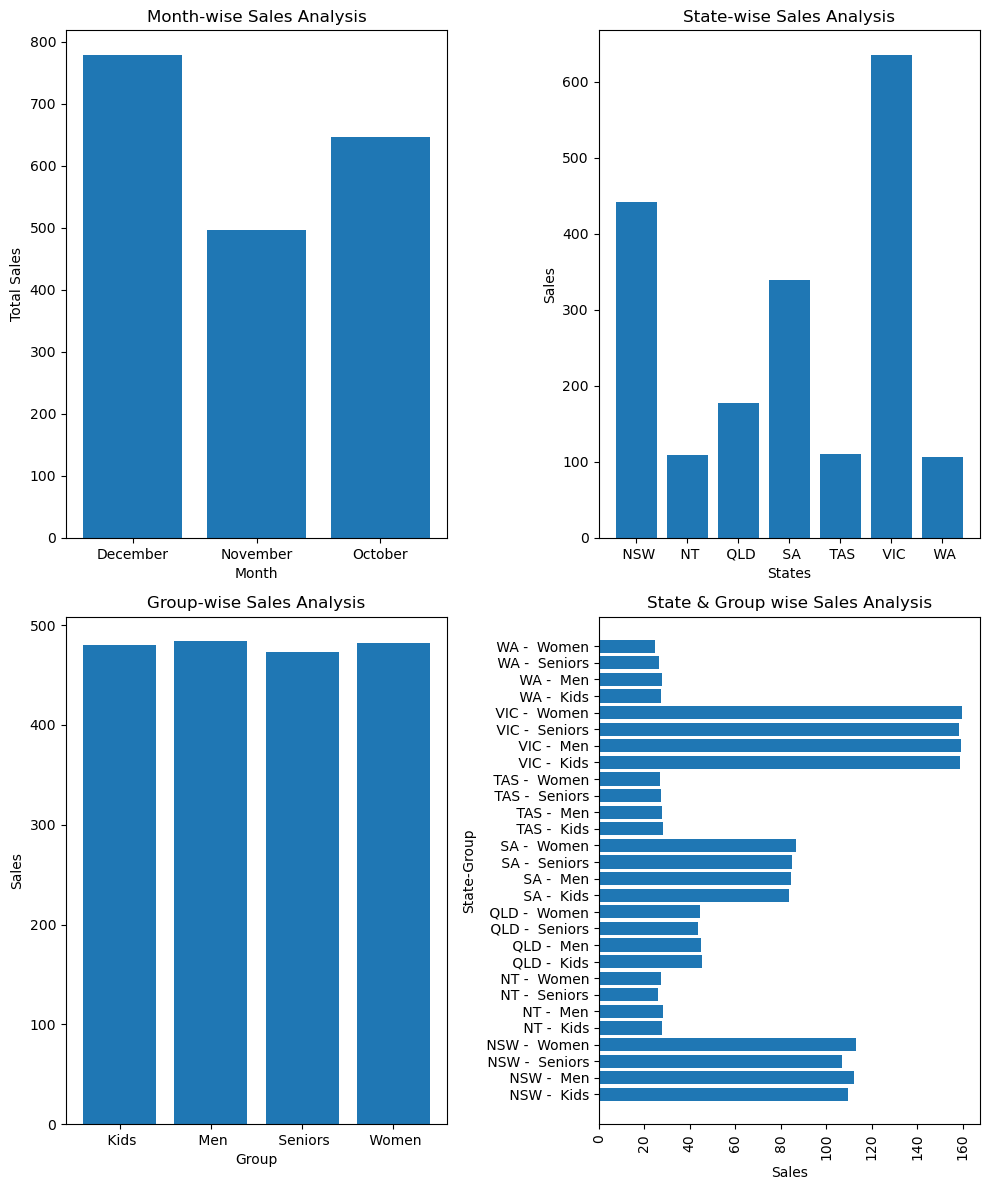

In [457]:
# Month wise analysis
plt.figure(figsize=(10,12))

plt.subplot(2,2,1)

plt.bar(monthly_sales.iloc[:, 0],monthly_sales.iloc[:, 1])
plt.title('Month-wise Sales Analysis')
plt.xlabel('Month')
plt.ylabel('Total Sales')


# State wise analysis

plt.subplot(2,2,2)

plt.bar(state_sales.iloc[:, 0],state_sales.iloc[:, 1])
plt.title('State-wise Sales Analysis')
plt.xlabel('States')
plt.ylabel('Sales')

# Group wise analysis
plt.subplot(2,2,3)

plt.bar(group_sales.iloc[:, 0],group_sales.iloc[:, 1])
plt.title('Group-wise Sales Analysis')
plt.xlabel('Group')
plt.ylabel('Sales')

# State and Group wise analysis
plt.subplot(2,2,4)

labels = (
    state_group_sales.iloc[:,0] + ' - ' +
    state_group_sales.iloc[:,1]
)
plt.barh(labels,state_group_sales.iloc[:, 2])
plt.title('State & Group wise Sales Analysis')
plt.xlabel('Sales')
plt.ylabel('State-Group')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

<h4 > Insights related to inventory or demand: </h4>

1. Decemeber month having highest sales need to maintain the Inventory
2. VIC,NSW States should maintain the high volume of inventory

<h4 > Insights related to Expansions: </h4>

1. Expand business in VIC state
2. Expand business in NSW state
3. VIC Resource allocation should maintain 

<h4 > Insights related to marketing: </h4>

1. Need to increase the sales in WA and NT states. We can promote more offers / campaigns
2. November and October months sales campaign we can offer to customers.

<h2 style="color:darkred"> 2. Data analysis </h2>
<h4 style="color:purple"> A. Perform descriptive statistical analysis on the data in the Sales and Unit columns. Utilize techniques such as mean, median, mode, and standard deviation for this analysis. </h4>

In [458]:
# Sales descriptive statistical analysis
sales_mean   = aus_sales4thQtr_2020['Sales'].mean()
sales_median = aus_sales4thQtr_2020['Sales'].median()
sales_mode   = aus_sales4thQtr_2020['Sales'].mode()
sales_std    = aus_sales4thQtr_2020['Sales'].std()

print(f"Sales Mean : {sales_mean}")
print(f"Sales Median : {sales_median}")
print(f"Sales Mode : {sales_mode}")
print(f"Sales Standard Deviation : {sales_std}")

Sales Mean : 0.25405433778449654
Sales Median : 0.19047619047619047
Sales Mode : 0    0.111111
Name: Sales, dtype: float64
Sales Standard Deviation : 0.20478417107280086


In [459]:
# Unit descriptive statistical analysis
unit_mean   = aus_sales4thQtr_2020['Unit'].mean()
unit_median = aus_sales4thQtr_2020['Unit'].median()
unit_mode   = aus_sales4thQtr_2020['Unit'].mode()
unit_std    = aus_sales4thQtr_2020['Unit'].std()

print(f"Unit Mean : {unit_mean}")
print(f"Unit Median : {unit_median}")
print(f"Unit Mode : {unit_mode}")
print(f"Unit Standard Deviation : {unit_std}")

Unit Mean : 0.25405433778449654
Unit Median : 0.19047619047619047
Unit Mode : 0    0.111111
Name: Unit, dtype: float64
Unit Standard Deviation : 0.20478417107280086


In [460]:
# Since both descriptive analysis is same checks for correlation
correlation = aus_sales4thQtr_2020['Unit'].corr(aus_sales4thQtr_2020['Sales'])

print("Correlation:", correlation)       # Strongly correlated

Correlation: 0.9999999999999999


<h4 style="color:purple"> B. Identify the group with the highest sales and the group with the lowest sales based on the data provided. </h4>

In [461]:
# Max and min for Group wise sales to find highest and lowest
group_hisale = group_sales.loc[group_sales['Sales'].idxmax()]
group_losale = group_sales.loc[group_sales['Sales'].idxmin()]

print(f"Highest Sale Group : {group_hisale.iloc[0]} & total sale is {group_hisale.iloc[1]}")
print(f"Lowest Sale Group  : {group_losale.iloc[0]} & total sale is {group_losale.iloc[1]}")

Highest Sale Group :  Men & total sale is 484.4444444444444
Lowest Sale Group  :  Seniors & total sale is 473.57142857142856


<h4 style="color:purple"> C. Identify the group with the highest and lowest sales based on the data provided. </h4>

In [462]:
# Max and min for Group wise sales to find highest and lowest
group_hisale = group_sales.loc[group_sales['Sales'].idxmax()]
group_losale = group_sales.loc[group_sales['Sales'].idxmin()]

print(f"Highest Sale Group : {group_hisale.iloc[0]} & total sale is {group_hisale.iloc[1]}")
print(f"Lowest Sale Group  : {group_losale.iloc[0]} & total sale is {group_losale.iloc[1]}")

Highest Sale Group :  Men & total sale is 484.4444444444444
Lowest Sale Group  :  Seniors & total sale is 473.57142857142856


<h4 style="color:purple"> D. Generate weekly, monthly, and quarterly reports to document and present the results of the analysis conducted.
</h4>


In [463]:
aus_sales4thQtr_2020.head()

,Date,Time,State,Group,Unit,Sales,Month
0,2020-10-01,Morning,WA,Kids,0.095238,0.095238,October
1,2020-10-01,Morning,WA,Men,0.095238,0.095238,October
2,2020-10-01,Morning,WA,Women,0.031746,0.031746,October
3,2020-10-01,Morning,WA,Seniors,0.206349,0.206349,October
4,2020-10-01,Afternoon,WA,Kids,0.015873,0.015873,October


In [464]:
# Already added the Month for analysis , now adding weekly and quarterly for analysis
# Adding week for data
aus_sales4thQtr_2020['Week'] = aus_sales4thQtr_2020['Date'].dt.isocalendar().week
aus_sales4thQtr_2020.head()

,Date,Time,State,Group,Unit,Sales,Month,Week
0,2020-10-01,Morning,WA,Kids,0.095238,0.095238,October,40
1,2020-10-01,Morning,WA,Men,0.095238,0.095238,October,40
2,2020-10-01,Morning,WA,Women,0.031746,0.031746,October,40
3,2020-10-01,Morning,WA,Seniors,0.206349,0.206349,October,40
4,2020-10-01,Afternoon,WA,Kids,0.015873,0.015873,October,40


In [465]:
# Adding week for Quarter
aus_sales4thQtr_2020['Quarter'] = aus_sales4thQtr_2020['Date'].dt.quarter
aus_sales4thQtr_2020.head()

,Date,Time,State,Group,Unit,Sales,Month,Week,Quarter
0,2020-10-01,Morning,WA,Kids,0.095238,0.095238,October,40,4
1,2020-10-01,Morning,WA,Men,0.095238,0.095238,October,40,4
2,2020-10-01,Morning,WA,Women,0.031746,0.031746,October,40,4
3,2020-10-01,Morning,WA,Seniors,0.206349,0.206349,October,40,4
4,2020-10-01,Afternoon,WA,Kids,0.015873,0.015873,October,40,4


In [466]:
# Group by weekly sales for reports
weekly_sales = aus_sales4thQtr_2020.groupby('Week')['Sales'].sum().reset_index()
weekly_sales

,Week,Sales
0,40,84.857143
1,41,152.777778
2,42,150.476190
3,43,151.587302
4,44,122.460317
5,45,113.809524
6,46,115.761905
7,47,115.380952
8,48,117.698413
9,49,169.412698


In [467]:
# Group by quarterly sales for reports
quarterly_sales = aus_sales4thQtr_2020.groupby('Quarter')['Sales'].sum().reset_index()
quarterly_sales

,Quarter,Sales
0,4,1920.650794


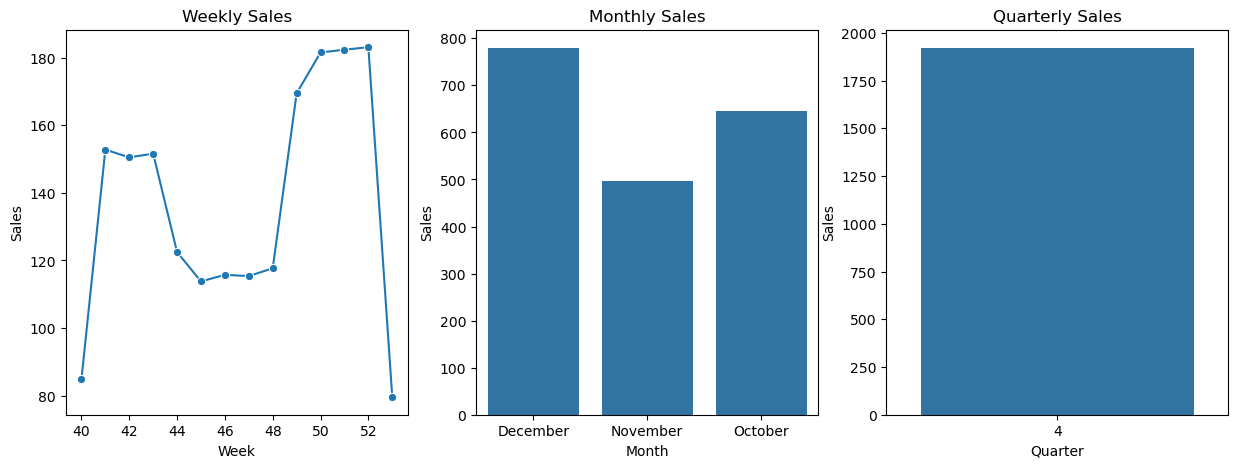

In [468]:
# Report based on analysis
plt.figure(figsize=(15,5))

# Weekly
plt.subplot(1,3,1)

sns.lineplot(
    x='Week',
    y='Sales',
    data=weekly_sales,
    marker='o'
)

plt.title('Weekly Sales')

# Monthly
plt.subplot(1,3,2)

sns.barplot(
    x='Month',
    y='Sales',
    data=monthly_sales
)

plt.title('Monthly Sales')

# Quarterly
plt.subplot(1,3,3)

sns.barplot(
    x='Quarter',
    y='Sales',
    data=quarterly_sales
)

plt.title('Quarterly Sales')

plt.show()

<h2 style="color:darkred"> 3. Data visualization </h2>
<h4 style="color:purple"> A. Use suitable data visualization libraries to construct a dashboard for the head of sales and marketing. The dashboard should encompass key parameters:</h4>

<h5>State-wise sales analysis for different demographic groups (kids, women, men, and seniors). </h5>
<h5>Group-wise sales analysis (Kids, Women, Men, and Seniors) across various states. </h5>

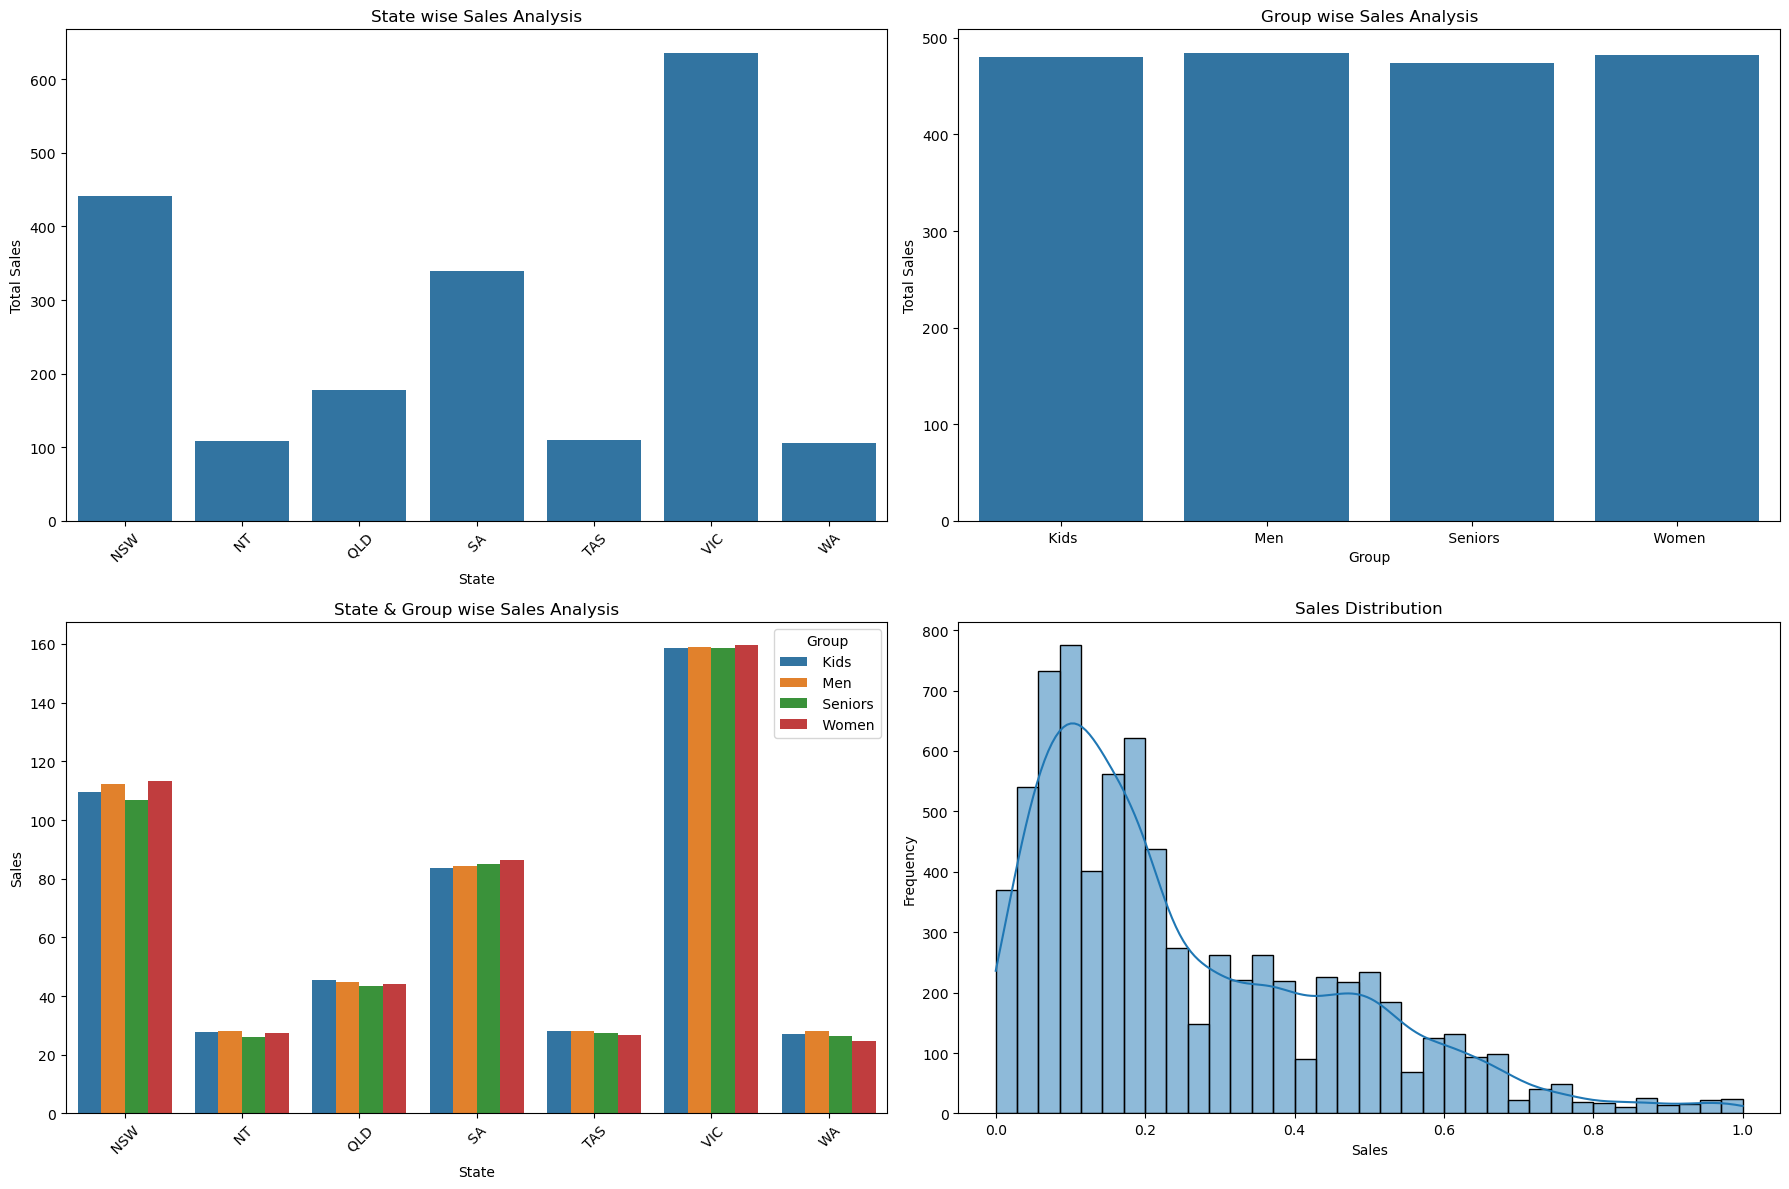

In [469]:
# State-wise sales analysis for different demographic groups (kids, women, men, and seniors)
plt.figure(figsize=(18,12))

# State wise sales analysis
plt.subplot(2,2,1)

sns.barplot(
    x='State',
    y='Sales',
    data=state_sales
)

plt.title('State wise Sales Analysis')
plt.xlabel('State')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

#Group wise sales analysis

plt.subplot(2,2,2)

sns.barplot(
    x='Group',
    y='Sales',
    data=group_sales
)

plt.title('Group wise Sales Analysis')
plt.xlabel('Group')
plt.ylabel('Total Sales')

# State & Group wise sales
plt.subplot(2,2,3)

sns.barplot(
    x='State',
    y='Sales',
    hue='Group',
    data=state_group_sales
)

plt.title('State & Group wise Sales Analysis')
plt.xlabel('State')
plt.ylabel('Sales')
plt.xticks(rotation=45)


# Sales 
plt.subplot(2,2,4)

sns.histplot(
    aus_sales4thQtr_2020['Sales'],
    kde=True
)

plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

<h5>Time-of-the-day analysis: Identify peak and off-peak sales periods to facilitate strategic planning for S&M teams. This information aids in designing programs like hyper-personalization and Next Best Offers to enhance sales. </h5>

In [470]:
# Time of the day analysis
timely_sales = aus_sales4thQtr_2020.groupby('Time')['Sales'].sum().reset_index()
timely_sales

,Time,Sales
0,Afternoon,643.857143
1,Evening,631.666667
2,Morning,645.126984


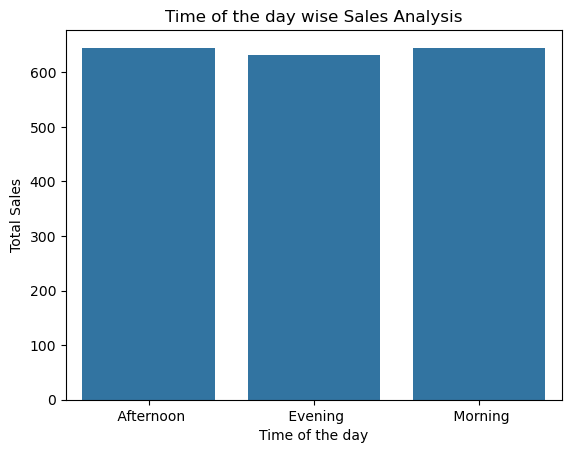

In [471]:
# Time of the day wise Sales Analysis Graph
sns.barplot(
    x='Time',
    y='Sales',
    data=timely_sales
)
plt.title('Time of the day wise Sales Analysis')
plt.xlabel('Time of the day')
plt.ylabel('Total Sales')
plt.show()

<h4> Insights related to time-of-day-wise sales analysis: </h4>

1. Morning and afternoon have a little bit higher sales when compared to evening sales.
2. Inventory forecast should take care
3. Resources should be a little more in the morning and afternoon.
4. Can plan for some strategies/campaigns in the morning and afternoon. It may have a chance to increase revenue.

<h4 style="color:purple"> Ensure the visualization is clear and accessible for effective decision-making by the head of sales and marketing (S&M).</h4>
The dashboard must contain daily, weekly, monthly, and quarterly charts.
(Any visualization library can be used for this purpose. However, since statistical analysis is being done, Seaborn is preferred.)


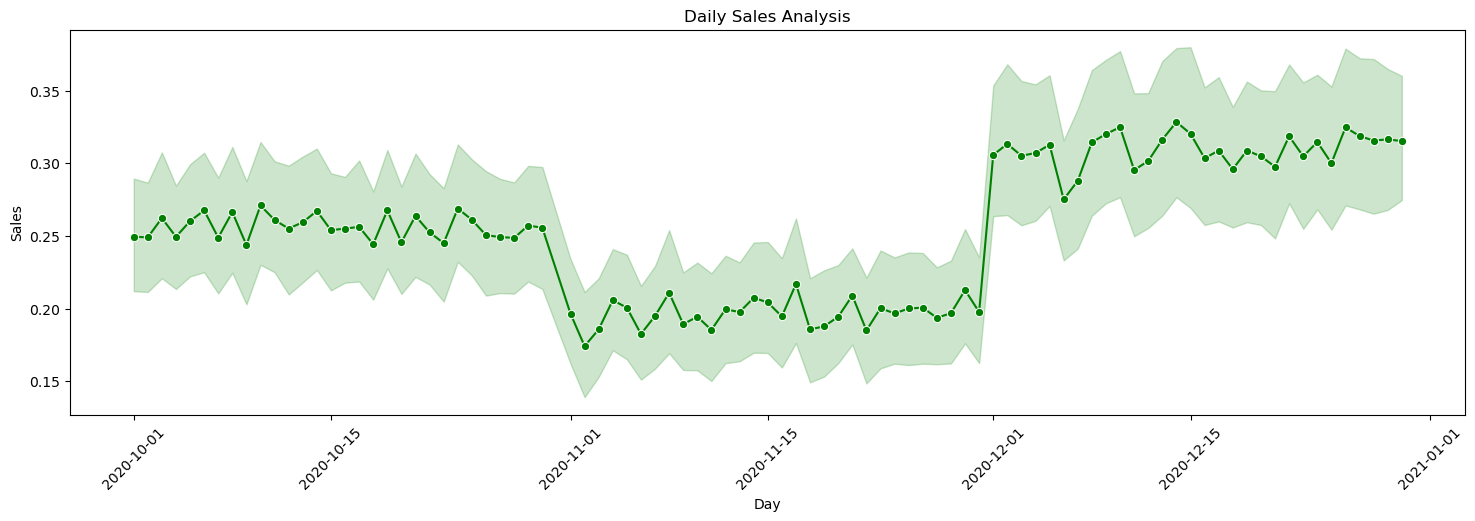

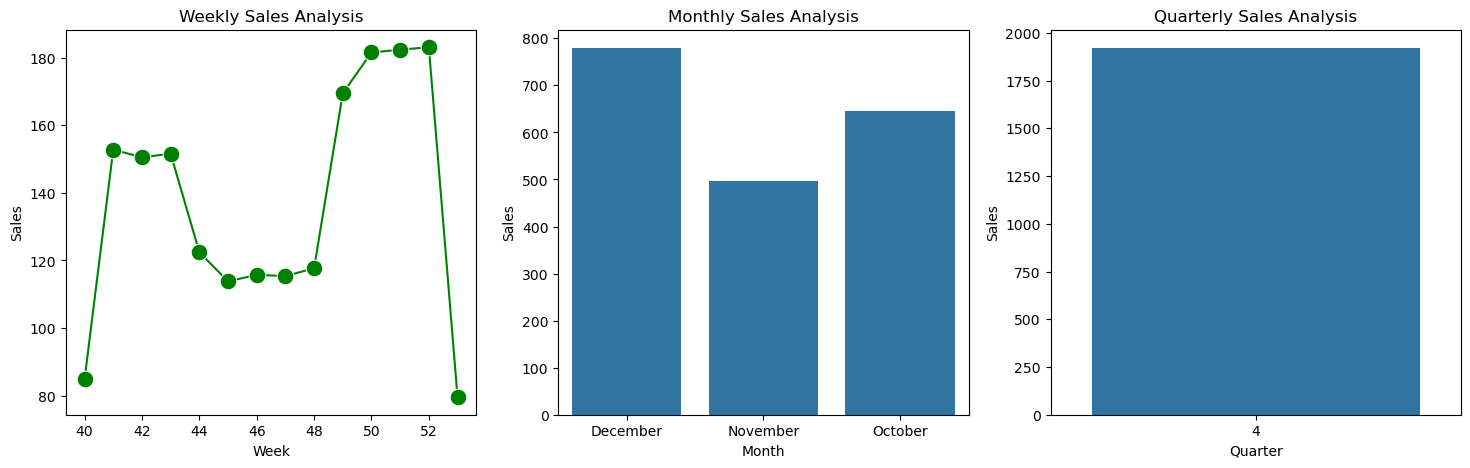

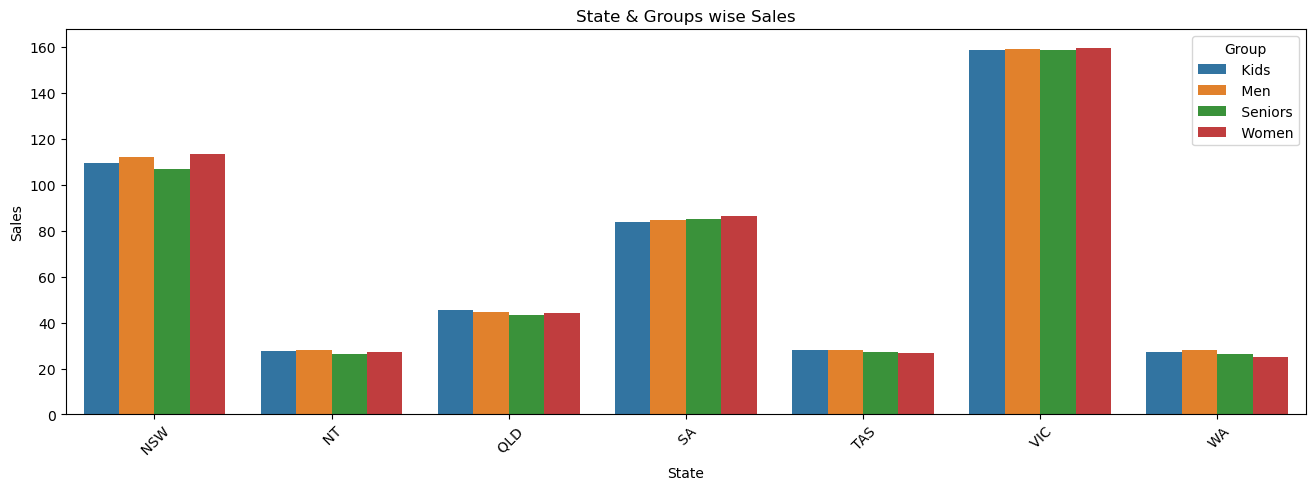

In [472]:
# Dashboard Daily,Weekly,Monthly,Quarterly Charts


plt.figure(figsize=(18,5))

sns.lineplot(
    x='Date',
    y='Sales',
    data=aus_sales4thQtr_2020,
    marker='o',
    color='green'
)

plt.xticks(rotation=45)

plt.xlabel('Day')
plt.ylabel('Sales')
plt.title('Daily Sales Analysis')

plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
sns.lineplot(
    x = 'Week',
    y = 'Sales',
    data = weekly_sales,
    marker='o',
    color='green',ms=12)

plt.xlabel('Week')
plt.ylabel('Sales')
plt.title('Weekly Sales Analysis')

plt.subplot(1,3,2)
sns.barplot(
    x = 'Month',
    y = 'Sales',
    data = monthly_sales)

plt.xlabel('Month')
plt.ylabel('Sales')
plt.title('Monthly Sales Analysis')

plt.subplot(1,3,3)
sns.barplot(
    x = 'Quarter',
    y = 'Sales',
    data = quarterly_sales)

plt.xlabel('Quarter')
plt.ylabel('Sales')
plt.title('Quarterly Sales Analysis')

#Additional Plots

# State and Group wise sales

plt.figure(figsize=(16,5))

sns.barplot(
    x='State',
    y='Sales',
    hue='Group',
    data=state_group_sales
)

plt.title('State & Groups wise Sales')
plt.xlabel('State')
plt.ylabel('Sales')
plt.xticks(rotation=45)

plt.show()


<h4 style="color:purple"> C. Include your recommendation and indicate why you are choosing the recommended visualization package.</h4>

For the AAL Sales Analysis Dashboard, the recommended visualization package is Seaborn. 
Seaborn is chosen because it's following the below:

1. Built on top of Matplotlib
2. Specifically designed for statistical data visualization
3. Easy to use for analytical dashboards
4. Provides visually attractive and informative graphs
5. Easy Handling of DataFrames. Seaborn integrates directly with Pandas DataFrames.
6. Best for Comparative Analysis.